# Transit extraction

Kind of a crazy hail mary idea here, considering there are about two days left in the competition. But, I have a plan to introduce more data diversity, better isolate the plane's atmospheric signal, and make the inputs to the model smaller.

This is a different strategy than the time point based sampling of the extracted frames I have been using. For it to work, I need to start with the planet frames (wavelengths, time points). So in theory, we could add it to the data preprocessing pipeline as an additional, maybe optional step.

Steps are, per-planet:

1. Identify transit and non-transit captures using the total signal
2. Split the planet image into transit and non-transit
3. Create n versions of each transit capture spectrum by subtracting each non-transit capture spectrum

On additional wrinkle here on the topic of spectroscopy in general - I expect anything interesting in the planet's atmosphere to absorb IR, so we are really looking for stuff that's missing from the star's spectrum during the transit. But I don't know if that is what is in the given ground truth spectra. It could be the planet's absorbance spectrum - i.e. strongly absorbed wavelengths show up as peaks, or it could be the transmitted spectrum, with the star's emission profile removed - i.g. strongly absorbed wavelengths show up as valleys.

If we had more time, we could make some test submission to try out both strategies - but at this point, we are out of time. Need to just show a neural net the data and let it sort out the relationships.

## Notebook set up

In [1]:
# Set notebook root to project root
from helper_functions import set_project_root

set_project_root()

# Standard library imports
from pathlib import Path
from random import shuffle

# Third party imports
import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

# Local imports
from ariel_data_preprocessing.utils import load_masked_frames
import configuration as config

# Make sure the figures directory exists
figures_dir = f'{config.FIGURES_DIRECTORY}/signal_extraction'
Path(figures_dir).mkdir(parents=True, exist_ok=True)

Working directory: /mnt/arkk/kaggle/ariel-data-challenge


## 1. Load corrected/extracted data for a sample planet

In [2]:
# Load corrected/extracted data for a sample planet
with h5py.File(f'{config.PROCESSED_DATA_DIRECTORY}/train.h5', 'r') as hdf:
    signal, planet_id = load_masked_frames(hdf, planet='random', return_id=True)

## 2. Find transit start and end indices

In [3]:
signal.shape
total_signal = np.sum(signal, axis=1)
total_signal.shape

(5426,)

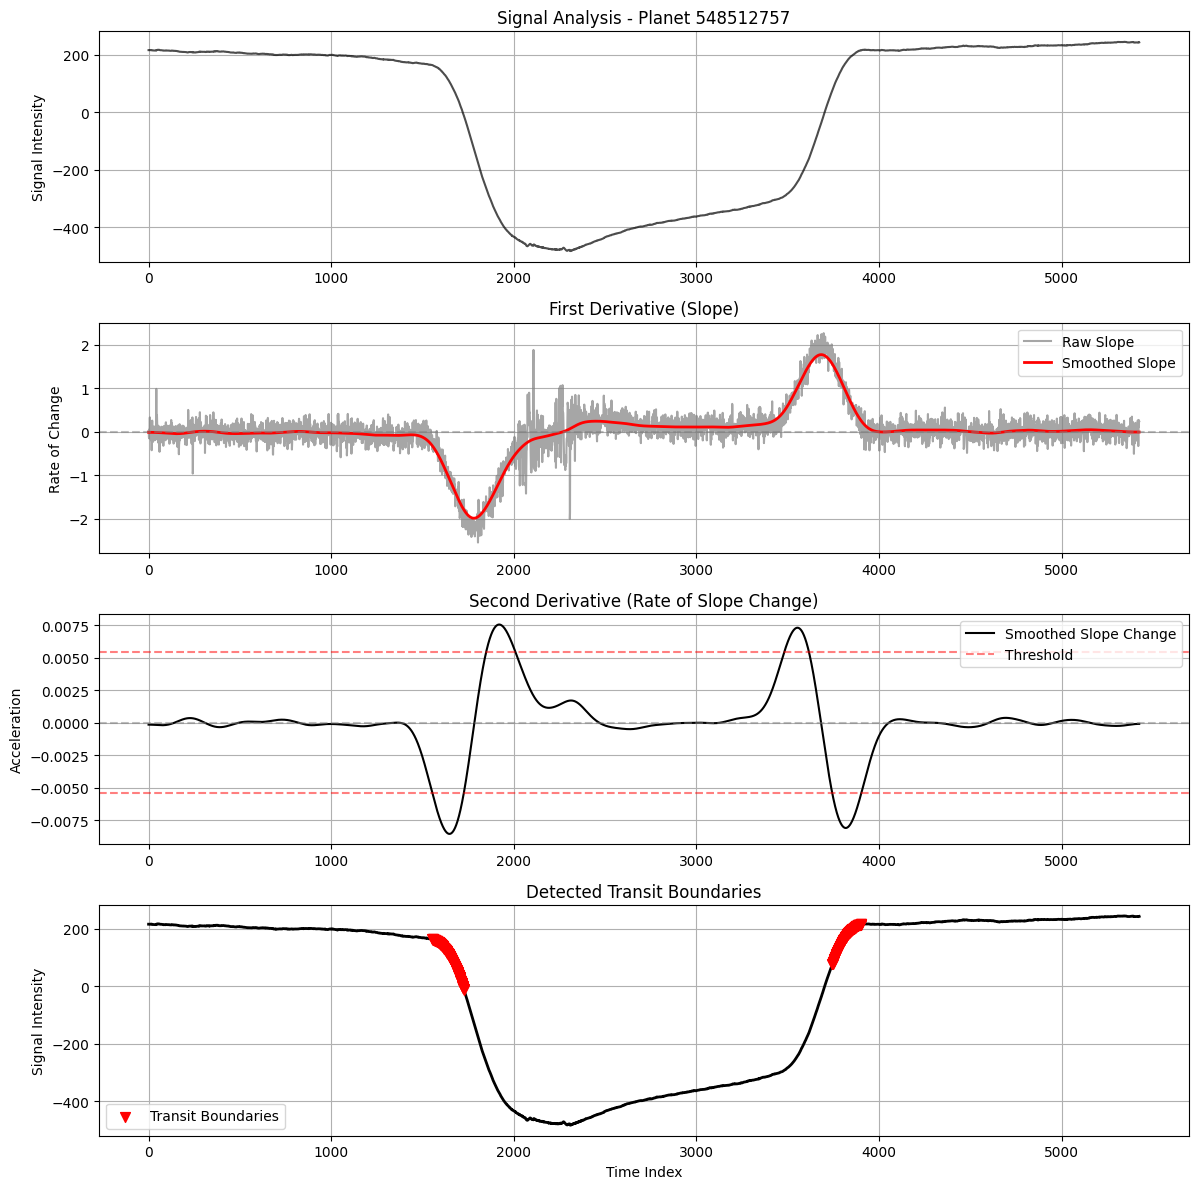

Potential transit boundary indices (rapid deceleration): [1554 1555 1556 1557 1558 1559 1560 1561 1562 1563 1564 1565 1566 1567
 1568 1569 1570 1571 1572 1573 1574 1575 1576 1577 1578 1579 1580 1581
 1582 1583 1584 1585 1586 1587 1588 1589 1590 1591 1592 1593 1594 1595
 1596 1597 1598 1599 1600 1601 1602 1603 1604 1605 1606 1607 1608 1609
 1610 1611 1612 1613 1614 1615 1616 1617 1618 1619 1620 1621 1622 1623
 1624 1625 1626 1627 1628 1629 1630 1631 1632 1633 1634 1635 1636 1637
 1638 1639 1640 1641 1642 1643 1644 1645 1646 1647 1648 1649 1650 1651
 1652 1653 1654 1655 1656 1657 1658 1659 1660 1661 1662 1663 1664 1665
 1666 1667 1668 1669 1670 1671 1672 1673 1674 1675 1676 1677 1678 1679
 1680 1681 1682 1683 1684 1685 1686 1687 1688 1689 1690 1691 1692 1693
 1694 1695 1696 1697 1698 1699 1700 1701 1702 1703 1704 1705 1706 1707
 1708 1709 1710 1711 1712 1713 1714 1715 1716 1717 1718 1719 1720 1721
 1722 1723 1724 1725 1726 3744 3745 3746 3747 3748 3749 3750 3751 3752
 3753 3754 3755 3756

In [15]:
# Calculate first derivative (slope)
slope = np.gradient(total_signal)

# Smooth the first derivative before calculating second derivative
smoothed_slope = gaussian_filter1d(slope, sigma=50)

# Calculate second derivative (rate of slope change) using smoothed slope
slope_change = np.gradient(smoothed_slope)

smoothed_slope_change = gaussian_filter1d(slope_change, sigma=50)

# Find regions where slope is changing most quickly
slope_change_threshold = np.std(smoothed_slope_change) * 2

# Find steep negative slope changes (rapid deceleration - transit start candidates)
transit_boundaries = np.where(smoothed_slope_change < -slope_change_threshold)[0]

# Plot comprehensive analysis
fig, axes = plt.subplots(4, 1, figsize=(12, 12))

# Raw signal
axes[0].plot(total_signal, color='black', alpha=0.7)
axes[0].set_title(f'Signal Analysis - Planet {planet_id}')
axes[0].set_ylabel('Signal Intensity')
axes[0].grid(True)

# First derivative (slope) - both raw and smoothed
axes[1].plot(slope, label='Raw Slope', alpha=0.7, color='grey')
axes[1].plot(smoothed_slope, label='Smoothed Slope', linewidth=2, color='red')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('First Derivative (Slope)')
axes[1].set_ylabel('Rate of Change')
axes[1].legend()
axes[1].grid(True)

# Second derivative (slope change)
axes[2].plot(smoothed_slope_change, label='Smoothed Slope Change', color='black')
axes[2].axhline(y=slope_change_threshold, color='red', linestyle='--', alpha=0.5, label='Threshold')
axes[2].axhline(y=-slope_change_threshold, color='red', linestyle='--', alpha=0.5)
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Second Derivative (Rate of Slope Change)')
axes[2].set_ylabel('Acceleration')
axes[2].legend()
axes[2].grid(True)

# Transit boundaries overlaid on original signal
axes[3].plot(total_signal, color='black', linewidth=2)
axes[3].scatter(transit_boundaries, total_signal[transit_boundaries], 
               color='red', s=50, marker='v', label='Transit Boundaries', zorder=5)
axes[3].set_title('Detected Transit Boundaries')
axes[3].set_xlabel('Time Index')
axes[3].set_ylabel('Signal Intensity')
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.show()

print(f"Potential transit boundary indices (rapid deceleration): {transit_boundaries}")
print(f"Slope change threshold: ±{slope_change_threshold:.4f}")

In [ ]:
# Smooth the signal first to reduce noise effects
smoothed_signal = gaussian_filter1d(total_signal, sigma=2)

# Then calculate the gradient
slope = np.gradient(smoothed_signal)

# Find significant slope changes that might indicate transit boundaries
slope_threshold = np.std(slope) * 2  # Adjust multiplier as needed

# Find steep negative slopes (transit start candidates)
transit_starts = np.where(slope < -slope_threshold)[0]

# Find steep positive slopes (transit end candidates)
transit_ends = np.where(slope > slope_threshold)[0]

print(f"Potential transit start indices: {transit_starts}")
print(f"Potential transit end indices: {transit_ends}")